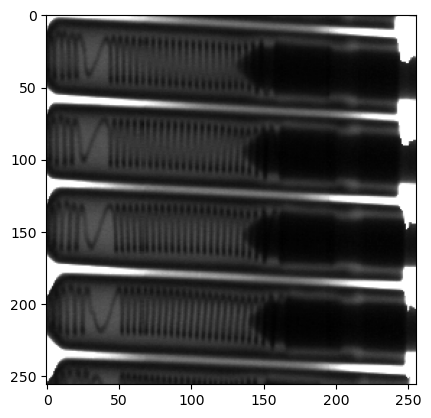

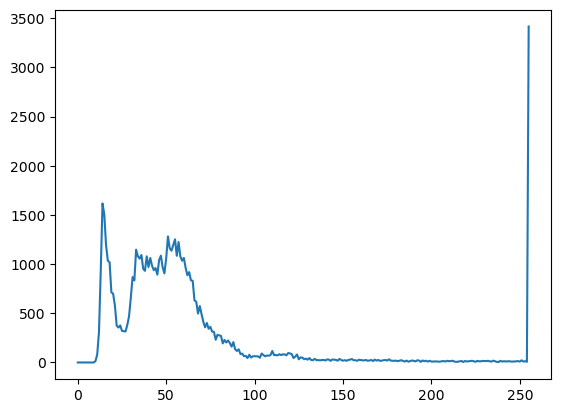

In [1]:
import cv2
import matplotlib.pyplot as plt

bougies = cv2.imread('BOUGIES.png', cv2.IMREAD_GRAYSCALE)
plt.imshow(bougies, cmap='gray')
plt.show()
hist = cv2.calcHist([bougies],[0],None,[256],[0,256])
plt.plot(hist)
plt.show()

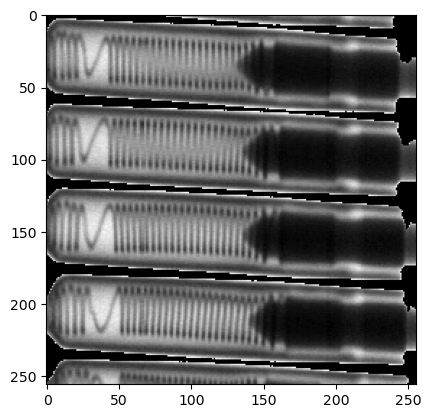

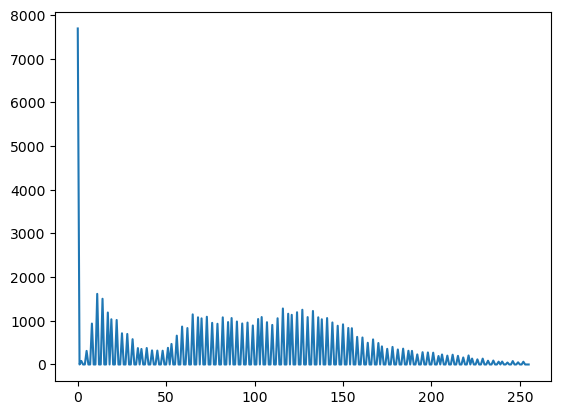

In [17]:
import numpy as np
from skimage import exposure

thres_value, thres_image = cv2.threshold(bougies, 100, 255, cv2.THRESH_BINARY)
expanded_img = exposure.rescale_intensity(bougies, in_range=(10, 100))
bougies_no_white = np.where(expanded_img == 255, 0, expanded_img)

plt.imshow(bougies_no_white, cmap='gray')
plt.show()

bougies_no_white_hist = cv2.calcHist([bougies_no_white.astype('uint8')], [0], None, [256], [0, 256])
plt.plot(bougies_no_white_hist)
plt.show()



# Explicación:

Primero, se tomó la imagen de las bujías y se mejoró el contraste de los detalles mediante una expansión de intensidad en un rango de 10 a 100 ya que la imagen original parecía estar en terminos de estas intensidades (ignorando el fondo que era totalmente blanco), lo que permitió hacer más visibles los detalles dentro de las bujías. Luego, se aplicó una umbralización simple para separar el fondo blanco de los detalles oscuros dentro de la bujía. Después, los pixeles de nivel 255 del fondo se convirtieron a una intensidad de 0 y volverse un fondo negro sin alterar los detalles de las bujías.